In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Загружаем данные
df = pd.read_csv('../data/traffic.csv')

# Первые строки
df.head()

,DateTime,Junction,Vehicles,ID
0,2015-11-01 00:00:00,1,15,20151101001
1,2015-11-01 01:00:00,1,13,20151101011
2,2015-11-01 02:00:00,1,10,20151101021
3,2015-11-01 03:00:00,1,7,20151101031
4,2015-11-01 04:00:00,1,9,20151101041


In [4]:
df.info()
df.isnull().sum()
df.duplicated().sum()

<class 'pandas.DataFrame'>
RangeIndex: 48120 entries, 0 to 48119
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   DateTime  48120 non-null  str  
 1   Junction  48120 non-null  int64
 2   Vehicles  48120 non-null  int64
 3   ID        48120 non-null  int64
dtypes: int64(3), str(1)
memory usage: 1.5 MB


np.int64(0)

In [5]:
# Преобразуем DateTime (автоопределение формата, либо явно указать)
df['DateTime'] = pd.to_datetime(df['DateTime'])  # pandas сам распознает ISO
# Или если хотите явно: 
# df['DateTime'] = pd.to_datetime(df['DateTime'], format='%Y-%m-%d %H:%M:%S')
df.set_index('DateTime', inplace=True)
df.drop('ID', axis=1, inplace=True)

df.head()

,Junction,Vehicles
DateTime,,
2015-11-01 00:00:00,1,15
2015-11-01 01:00:00,1,13
2015-11-01 02:00:00,1,10
2015-11-01 03:00:00,1,7
2015-11-01 04:00:00,1,9


In [6]:
# Посмотрим, сколько уникальных перекрестков
df['Junction'].unique()   # [1,2,3,4]

# Сколько записей на каждый Junction
df.groupby('Junction').size()

Junction
1    14592
2    14592
3    14592
4     4344
dtype: int64

In [7]:
for j in df['Junction'].unique():
    subset = df[df['Junction'] == j]
    print(f"Junction {j}: {subset.index.min()} -> {subset.index.max()}, rows={len(subset)}")

Junction 1: 2015-11-01 00:00:00 -> 2017-06-30 23:00:00, rows=14592
Junction 2: 2015-11-01 00:00:00 -> 2017-06-30 23:00:00, rows=14592
Junction 3: 2015-11-01 00:00:00 -> 2017-06-30 23:00:00, rows=14592
Junction 4: 2017-01-01 00:00:00 -> 2017-06-30 23:00:00, rows=4344


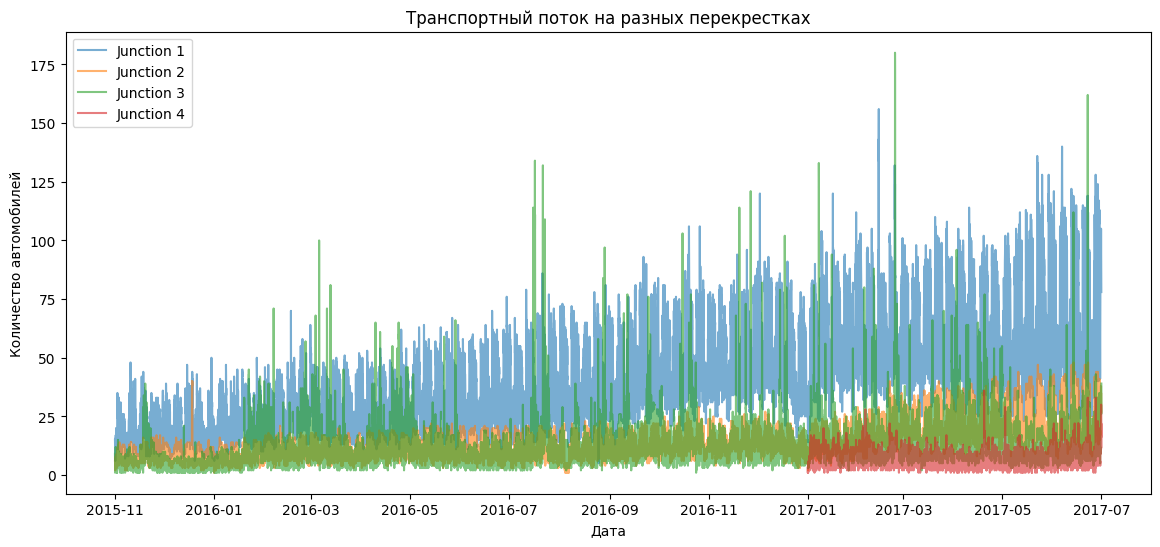

In [8]:
# Общий график для всех перекрестков (с разными цветами)
plt.figure(figsize=(14,6))
for j in [1,2,3,4]:
    subset = df[df['Junction'] == j]
    plt.plot(subset.index, subset['Vehicles'], label=f'Junction {j}', alpha=0.6)
plt.legend()
plt.title('Транспортный поток на разных перекрестках')
plt.xlabel('Дата')
plt.ylabel('Количество автомобилей')
plt.show()

In [9]:
from statsmodels.tsa.stattools import adfuller

series = df[df['Junction']==1]['Vehicles'].copy()
result = adfuller(series.dropna())
print(f'ADF Statistic: {result[0]:.4f}')
print(f'p-value: {result[1]:.4f}')
if result[1] <= 0.05:
    print("Ряд стационарен")
else:
    print("Ряд нестационарен")

ADF Statistic: -7.1481
p-value: 0.0000
Ряд стационарен


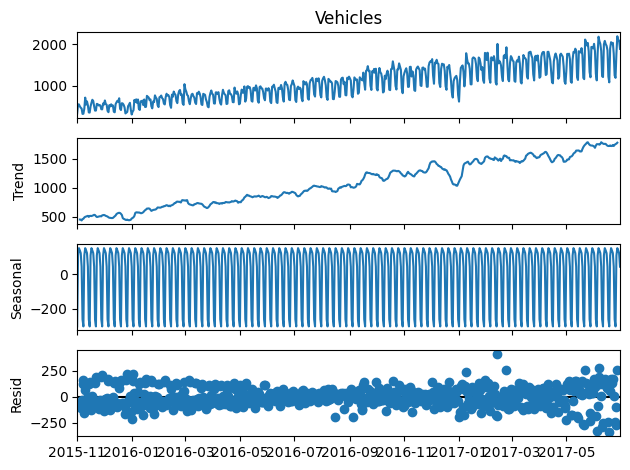

In [10]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Возьмем ежедневную агрегацию для наглядности
daily = series.resample('D').sum()
decomp = seasonal_decompose(daily, model='additive', period=7)  # недельная сезонность
decomp.plot()
plt.show()

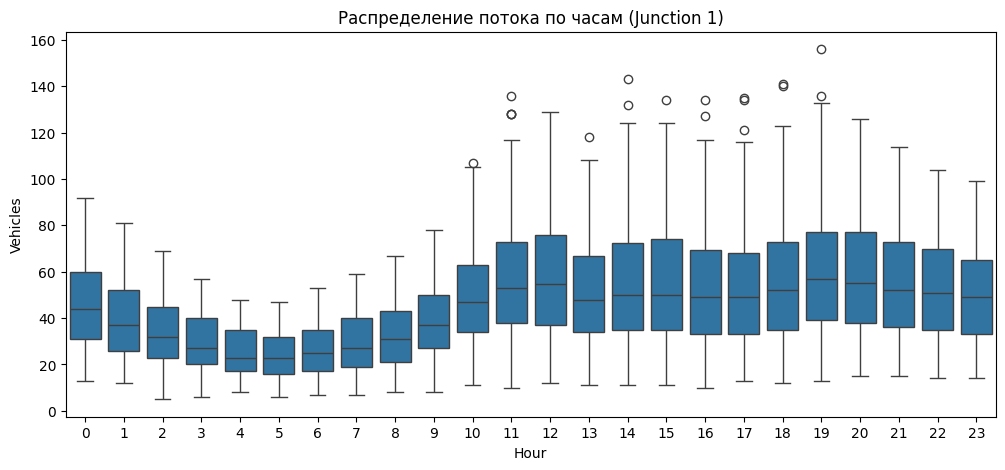

In [11]:
# Добавим признаки: час, день недели, месяц
df['Hour'] = df.index.hour
df['DayOfWeek'] = df.index.dayofweek   # 0=пн, 6=вс
df['Month'] = df.index.month

# Boxplot по часам для Junction 1
plt.figure(figsize=(12,5))
sns.boxplot(data=df[df['Junction']==1], x='Hour', y='Vehicles')
plt.title('Распределение потока по часам (Junction 1)')
plt.show()

In [12]:
# Для Junction 1 создадим полный диапазон дат-часов
j1 = df[df['Junction']==1].copy()
full_range = pd.date_range(start=j1.index.min(), end=j1.index.max(), freq='h')
j1_reindexed = j1.reindex(full_range)
missing_hours = j1_reindexed['Vehicles'].isnull().sum()
print(f"Пропущенных часов в Junction 1: {missing_hours}")

Пропущенных часов в Junction 1: 0


In [13]:
# Выберем только перекрестки 1,2,3 (у них почти полные ряды)
df_clean = df[df['Junction'].isin([1,2,3])].copy()
# Удалим строки с NaN (если есть)
df_clean.dropna(subset=['Vehicles'], inplace=True)
# Сохраним в CSV
df_clean.to_csv('../data/traffic_clean.csv')
print(f"Сохранено {len(df_clean)} записей.")

Сохранено 43776 записей.


In [14]:
Q1 = df_clean['Vehicles'].quantile(0.25)
Q3 = df_clean['Vehicles'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = df_clean[(df_clean['Vehicles'] < lower) | (df_clean['Vehicles'] > upper)]
print(f"Количество аномалий (IQR): {len(outliers)}")

Количество аномалий (IQR): 2823
